In [ ]:
import random
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import get_linear_schedule_with_warmup

: 

## config

In [ ]:
# 1. Đường dẫn file (Paths)
DATA_FILE = "/kaggle/input/datasets/phantrihieu/absa-reviews-phone-on-shopee/absa_training_flat.jsonl"
MODEL_SAVE_PATH = "best_absa_model.pth"

# 2. Tham số mô hình (Model Parameters)
PHOBERT_VERSION = "vinai/phobert-base"
MAX_LEN = 64               # Độ dài tối đa của câu sau khi tokenize
LSTM_HIDDEN_SIZE = 256      # Kích thước hidden state của Bi-LSTM
LSTM_LAYERS = 1             # Số lớp LSTM
FREEZE_PHOBERT = False      # Đặt True nếu muốn đóng băng PhoBERT để train nhanh hơn

# 3. Tham số huấn luyện (Training Hyperparameters)
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 2e-5        # Khuyến nghị: 2e-5 đến 5e-5 nếu Fine-tune PhoBERT; 1e-3 nếu Freeze PhoBERT

# 4. Nhãn phân loại (Labels)
SENTIMENT_MAP = {'none': 0, 'positive': 1, 'neutral': 2, 'negative': 3}
ID_TO_SENTIMENT = {v: k for k, v in SENTIMENT_MAP.items()}

# 5. Thiết bị (Cấu hình tự động nhận diện GPU/CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 6. Cấu hình Seed (Đảm bảo tái lập kết quả)
SEED = 42

def set_seed(seed_value):
    """Cố định seed cho toàn bộ môi trường để tái lập kết quả"""
    # 1. Cố định cho Python và Hashing
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Cố định cho Numpy
    np.random.seed(seed_value)
    
    # 3. Cố định cho PyTorch (CPU)
    torch.manual_seed(seed_value)
    
    # 4. Cố định cho PyTorch (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value) # Dành cho multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
def load_and_group_data(file_path):
    print("Reading data...")
    df = pd.read_json(file_path, lines=True)
    unique_aspects = sorted(df['aspect'].dropna().unique().tolist())
    
    # Thêm include_groups=False để tắt cảnh báo Pandas
    grouped = df.groupby('text').apply(
        lambda x: dict(zip(x['aspect'], x['sentiment'])),
        include_groups=False
    ).reset_index(name='aspect_sentiments')
    
    # ... (phần code bên dưới giữ nguyên)
    
    texts = grouped['text'].tolist()
    aspect_dicts = grouped['aspect_sentiments'].tolist()
    
    labels = []
    for d in aspect_dicts:
        label_row = []
        for asp in unique_aspects:
            sent = d.get(asp, 'none')
            label_row.append(SENTIMENT_MAP.get(sent, 0))
        labels.append(label_row)
        
    return texts, labels, unique_aspects

class ABSADataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # Gọi trực tiếp tokenizer thay vì dùng encode_plus
        encoding = self.tokenizer(
            text, 
            add_special_tokens=True, 
            max_length=self.max_len,
            padding='max_length', 
            truncation=True,
            return_attention_mask=True, 
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [ ]:
# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH
# ==========================================
class HighwayNetwork(nn.Module):
    def __init__(self, size):
        super(HighwayNetwork, self).__init__()
        self.transform = nn.Linear(size, size)
        self.gate = nn.Linear(size, size)

    def forward(self, x):
        t = torch.sigmoid(self.gate(x))
        h = torch.relu(self.transform(x))
        return t * h + (1.0 - t) * x

# --- THÊM LỚP ATTENTION ---
class AspectAwareAttention(nn.Module):
    def __init__(self, hidden_size, aspect_dim):
        super(AspectAwareAttention, self).__init__()
        # Dùng Additive Attention để học tương tác giữa Khía cạnh và Từ ngữ
        self.W_h = nn.Linear(hidden_size, hidden_size)
        self.W_a = nn.Linear(aspect_dim, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out, aspect_embed):
        # lstm_out shape: [batch_size, seq_len, hidden_size]
        # aspect_embed shape: [batch_size, num_aspects, aspect_dim]
        
        # 1. Biến đổi LSTM out
        H = self.W_h(lstm_out) # [batch_size, seq_len, hidden_size]
        H = H.unsqueeze(1)     # [batch_size, 1, seq_len, hidden_size]
        
        # 2. Biến đổi Aspect Embeddings
        A = self.W_a(aspect_embed) # [batch_size, num_aspects, hidden_size]
        A = A.unsqueeze(2)         # [batch_size, num_aspects, 1, hidden_size]
        
        # 3. Tính điểm Attention Score cho MỖI từ đối với MỖI khía cạnh
        M = torch.tanh(H + A)  # Broadcasting -> [batch_size, num_aspects, seq_len, hidden_size]
        scores = self.v(M).squeeze(-1) # [batch_size, num_aspects, seq_len]
        
        # 4. Softmax để chuẩn hóa thành trọng số (tổng các từ = 1)
        attn_weights = torch.softmax(scores, dim=2) # [batch_size, num_aspects, seq_len]
        
        # 5. Nhân trọng số với LSTM out để ra Context Vector cho TỪNG khía cạnh
        # [B, num_aspects, seq_len] x [B, seq_len, H] -> [B, num_aspects, H]
        context = torch.bmm(attn_weights, lstm_out) 
        
        return context, attn_weights

# --- CẬP NHẬT MÔ HÌNH CHÍNH ---
class PhoBERT_BiLSTM_Highway_ABSA(nn.Module):
    def __init__(self, num_aspects, num_sentiments=4, dropout_rate=0.3):
        super(PhoBERT_BiLSTM_Highway_ABSA, self).__init__()
        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments
        
        self.phobert = AutoModel.from_pretrained(PHOBERT_VERSION)
        
        if FREEZE_PHOBERT:
            for param in self.phobert.parameters():
                param.requires_grad = False
            
        self.bilstm = nn.LSTM(input_size=768, hidden_size=LSTM_HIDDEN_SIZE, 
                              num_layers=LSTM_LAYERS, bidirectional=True, batch_first=True)
        
        highway_size = LSTM_HIDDEN_SIZE * 2
        
        # ================= NEW: MẢNG EMBEDDING CHO KHÍA CẠNH =================
        # Bảng tra cứu vector cho từng khía cạnh (VD: 6 khía cạnh, mỗi cái là vector size 512)
        self.aspect_embeddings = nn.Embedding(num_aspects, highway_size)
        
        # ================= NEW: GỌI ASPECT-AWARE ATTENTION =================
        self.attention = AspectAwareAttention(hidden_size=highway_size, aspect_dim=highway_size)
        
        self.highway = HighwayNetwork(size=highway_size)
        self.dropout = nn.Dropout(dropout_rate)
        
        # ================= UPDATE: ĐẦU RA PHÂN LOẠI LÀ num_sentiments =================
        # Vì Attention đã trích xuất riêng 1 context_vector cho mỗi khía cạnh, 
        # ta chỉ cần dự đoán sentiment cho từng vector đó độc lập.
        self.classifier = nn.Linear(highway_size, num_sentiments)

    def forward(self, input_ids, attention_mask, return_attention=False):
        phobert_out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = phobert_out.last_hidden_state
        lstm_out, _ = self.bilstm(sequence_output)
        
        # 1. Tạo tensor ID của toàn bộ các khía cạnh: [0, 1, 2, ..., num_aspects-1]
        aspect_ids = torch.arange(self.num_aspects).to(input_ids.device)
        # 2. Lấy Embeddings cho các khía cạnh và nhân bản ra theo Batch Size
        batch_size = input_ids.size(0)
        # expand thành shape: [batch_size, num_aspects, highway_size]
        aspect_embeds = self.aspect_embeddings(aspect_ids).unsqueeze(0).expand(batch_size, -1, -1)
        
        # 3. Nạp cả LSTM_out (CÂU) và Aspect_Embeds (KHÍA CẠNH) vào Attention
        # Kết quả attn_out: [batch_size, num_aspects, highway_size]
        attn_out, attn_weights = self.attention(lstm_out, aspect_embeds) 
        
        highway_out = self.highway(attn_out)
        dropped_out = self.dropout(highway_out)
        
        # 4. Phân loại cho TỪNG khía cạnh (Pytorch tự động xử lý batch đa chiều cho Linear)
        # Logits ban đầu: [batch_size, num_aspects, num_sentiments]
        logits = self.classifier(dropped_out)
        if return_attention:
            return logits, attn_weights
        
        return logits

class Baseline_PhoBERT_BiLSTM_ABSA(nn.Module):
    def __init__(self, num_aspects, num_sentiments=4, dropout_rate=0.3):
        super(Baseline_PhoBERT_BiLSTM_ABSA, self).__init__()
        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments
        
        self.phobert = AutoModel.from_pretrained(PHOBERT_VERSION)
        if FREEZE_PHOBERT:
            for param in self.phobert.parameters():
                param.requires_grad = False
                
        self.bilstm = nn.LSTM(input_size=768, hidden_size=LSTM_HIDDEN_SIZE, 
                              num_layers=LSTM_LAYERS, bidirectional=True, batch_first=True)
        
        self.dropout = nn.Dropout(dropout_rate)
        
        highway_size = LSTM_HIDDEN_SIZE * 2
        
        # Classifier dồn toàn bộ trọng trách dự đoán (Không dùng Attention, không có Aspect Embeddings)
        # Đầu ra là 1 vector lớn có kích thước (num_aspects * num_sentiments)
        self.classifier = nn.Linear(highway_size, num_aspects * num_sentiments)

    def forward(self, input_ids, attention_mask):
        phobert_out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = phobert_out.last_hidden_state
        
        lstm_out, _ = self.bilstm(sequence_output)
        
        # Tạo vector biểu diễn toàn bộ câu bằng Mean Pooling có xét Mask 
        # (Không lấy trung bình vào các ký tự <pad>)
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(lstm_out.size()).float()
        sum_embeddings = torch.sum(lstm_out * input_mask_expanded, 1)
        sum_mask = input_mask_expanded.sum(1)
        sum_mask = torch.clamp(sum_mask, min=1e-9)
        
        pooled_output = sum_embeddings / sum_mask # Shape: [batch_size, highway_size]
        
        dropped_out = self.dropout(pooled_output) 
        
        # Dự đoán phân loại
        logits = self.classifier(dropped_out) # Shape: [batch_size, num_aspects * num_sentiments]
        
        # Tách (reshape) mảng 2 chiều thành mảng 3 chiều để hàm Loss có thể tính được như bản gốc
        logits = logits.view(-1, self.num_aspects, self.num_sentiments)
        
        return logits

In [ ]:
# ==========================================
# 3. HÀM TRAIN & EVALUATE
# ==========================================
def train_epoch(model, data_loader, loss_fn, optimizer, device, epoch, total_epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    # Format TQDM đẹp hơn, hiện tiến trình chạy
    loop = tqdm(data_loader, leave=False, bar_format="{l_bar}{bar:30}{r_bar}")
    loop.set_description(f"Epoch [{epoch}/{total_epochs}] Train")
    
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)

        logits_flat = logits.view(-1, logits.size(-1))
        labels_flat = labels.view(-1)
        
        loss = loss_fn(logits_flat, labels_flat)
        total_loss += loss.item()
        
        loss.backward()
        # THÊM DÒNG NÀY: Tránh nổ gradient (Exploding Gradients) cho LSTM/PhoBERT
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        scheduler.step()

        preds = torch.argmax(logits_flat, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_flat.cpu().numpy())
        
        # Hiển thị loss realtime trên thanh TQDM
        loop.set_postfix(loss=f"{loss.item():.4f}")

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(data_loader), acc, f1

def eval_model(model, data_loader, loss_fn, device, phase="Val  ", epoch=None, total_epochs=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    loop = tqdm(data_loader, leave=False, bar_format="{l_bar}{bar:30}{r_bar}")
    if epoch:
        loop.set_description(f"Epoch [{epoch}/{total_epochs}] {phase.strip()}")
    else:
        loop.set_description(f"{phase}")

    with torch.no_grad():
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            
            logits_flat = logits.view(-1, logits.size(-1))
            labels_flat = labels.view(-1)
            
            loss = loss_fn(logits_flat, labels_flat)
            total_loss += loss.item()

            preds = torch.argmax(logits_flat, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_flat.cpu().numpy())
            
            loop.set_postfix(loss=f"{loss.item():.4f}")

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(data_loader), acc, f1, all_preds, all_labels

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_f1'], 'b-', label='Train F1')
    plt.plot(epochs, history['val_f1'], 'r-', label='Val F1')
    plt.title('F1-Macro Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1')
    plt.legend()

    plt.tight_layout()
    plt.show()

Set SEED = 42 for reproducibility.
Using device: cuda
Reading data...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Auto-calculated Class Weights: tensor([0.5484, 1.3446, 6.2567, 3.2173], device='cuda:0')


Train | Loss: 1.5155 | Acc: 0.7825 | F1: 0.3987
Val   | Loss: 1.3752 | Acc: 0.8670 | F1: 0.5396
>> Saved Best Model (F1 improved)!


...

Train | Loss: 1.0639 | Acc: 0.9903 | F1: 0.9388
Val   | Loss: 1.2788 | Acc: 0.9329 | F1: 0.6614


Train | Loss: 1.0577 | Acc: 0.9930 | F1: 0.9555
Val   | Loss: 1.2787 | Acc: 0.9331 | F1: 0.6628


Train | Loss: 1.0543 | Acc: 0.9944 | F1: 0.9625
Val   | Loss: 1.2795 | Acc: 0.9363 | F1: 0.6641
>> Saved Best Model (F1 improved)!


Train | Loss: 1.0520 | Acc: 0.9961 | F1: 0.9732
Val   | Loss: 1.2786 | Acc: 0.9335 | F1: 0.6623


Train | Loss: 1.0491 | Acc: 0.9969 | F1: 0.9785
Val   | Loss: 1.2782 | Acc: 0.9349 | F1: 0.6642
>> Saved Best Model (F1 improved)!

Training completed. Plotting history...


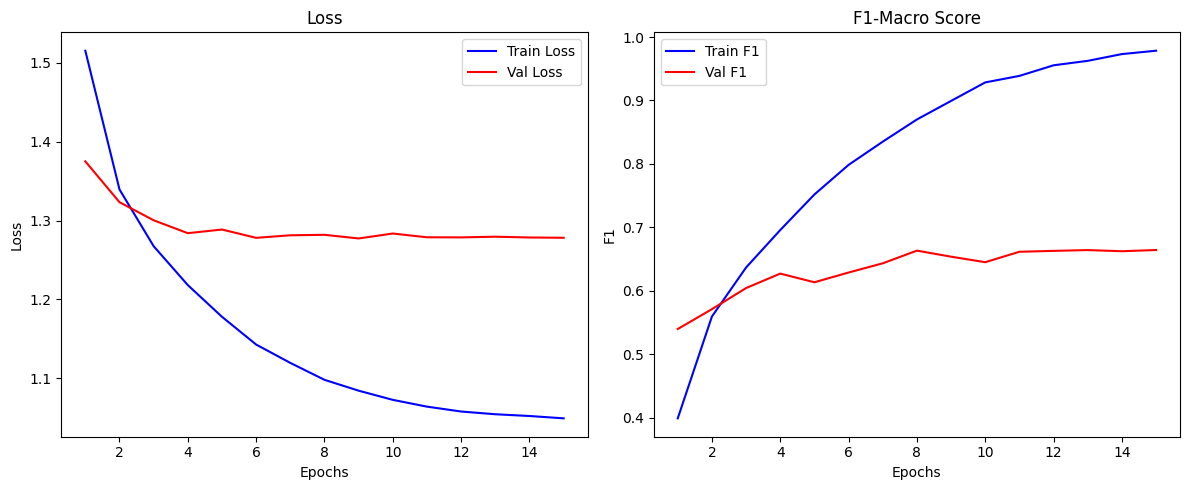


       FINAL EVALUATION ON TEST SET      


Test Loss: 1.2663
Test Accuracy: 0.9399
Test F1-Macro: 0.6641

Detailed Classification Report (For all Aspects & Sentiments):
              precision    recall  f1-score   support

        none       0.98      0.97      0.97      8336
    positive       0.84      0.86      0.85      1360
     neutral       0.19      0.23      0.21        80
    negative       0.59      0.66      0.63       234

    accuracy                           0.94     10010
   macro avg       0.65      0.68      0.66     10010
weighted avg       0.94      0.94      0.94     10010


         INFERENCE (TEST CASES)          

[Test Case 1]: Điện thoại thiết kế rất đẹp và sang trọng, chụp ảnh sắc nét, shop giao hàng hỏa tốc luôn. Rất đáng tiền!


TypeError: Baseline_PhoBERT_BiLSTM_ABSA.forward() got an unexpected keyword argument 'return_attention'

In [ ]:
# ==========================================
# 4. CHƯƠNG TRÌNH CHÍNH
# ==========================================
if __name__ == "__main__":
    # --- GỌI HÀM SET SEED Ở ĐÂY ---
    set_seed(SEED)
    print(f"Set SEED = {SEED} for reproducibility.")
    # ------------------------------

    print(f"Using device: {DEVICE}")

    # 1. Load Data
    texts, labels, unique_aspects = load_and_group_data(DATA_FILE)

    # Bước A: Biến mảng nhãn thành chuỗi để làm key phân tầng (Ví dụ: [0,1,0,3] -> "0_1_0_3")
    str_labels = ["_".join(map(str, label_row)) for label_row in labels]

    # Bước B: Xử lý lỗi "The least populated class has only 1 member" của sklearn
    # train_test_split bắt buộc mỗi nhóm phải có ít nhất 2 mẫu để chia. 
    # Ta sẽ gom các tổ hợp nhãn hiếm (chỉ xuất hiện 1 lần) thành nhóm "rare_class".
    label_counts = Counter(str_labels)
    safe_stratify_labels = [lbl if label_counts[lbl] >= 2 else "rare_class" for lbl in str_labels]
    
    # Ở hàm train_test_split, bạn cũng nên dùng chung SEED
    train_texts, temp_texts, train_labels, temp_labels, _, temp_safe_labels = train_test_split(
        texts, labels, safe_stratify_labels, 
        test_size=0.3, 
        random_state=SEED, 
        stratify=safe_stratify_labels
    )

    # Bước D: Cập nhật lại key phân tầng cho tập Temp để chia Val/Test
    temp_counts = Counter(temp_safe_labels)
    temp_stratify_labels = [lbl if temp_counts[lbl] >= 2 else "rare_class" for lbl in temp_safe_labels]
    
    # Bước E: Chia Val (10%) và Test (10%) từ Temp có phân tầng
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, 
        test_size=0.5, 
        random_state=SEED, 
        stratify=temp_stratify_labels
    )


    # ... (phần code bên dưới giữ nguyên)

    # 2. Tokenizer & DataLoader
    tokenizer = AutoTokenizer.from_pretrained(PHOBERT_VERSION)
    
    train_dataset = ABSADataset(train_texts, train_labels, tokenizer, MAX_LEN)
    val_dataset = ABSADataset(val_texts, val_labels, tokenizer, MAX_LEN)
    test_dataset = ABSADataset(test_texts, test_labels, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # 3. Khởi tạo Model
    model = Baseline_PhoBERT_BiLSTM_ABSA(num_aspects=len(unique_aspects)).to(DEVICE)
    
    # THÊM CLASS WEIGHT ĐỂ TRỊ MẤT CÂN BẰNG DỮ LIỆU
    # Trọng số: None (0.1) - ít quan tâm | Positive (1.0), Neutral (1.5), Negative (1.5) - bắt buộc phải học
    # ... (Sau khi chia train_test_split và trước khi khởi tạo loss_fn) ...

    # 1. Trải phẳng toàn bộ nhãn trong tập train thành mảng 1 chiều
    all_train_labels_flat = np.array(train_labels).flatten()
    
    # 2. Tự động tính toán trọng số cân bằng (balanced)
    classes = np.unique(all_train_labels_flat)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=all_train_labels_flat)
    
    # 3. Chuyển sang tensor và gán vào Loss function
    smoothed_weights = np.sqrt(weights)
    class_weights = torch.tensor(smoothed_weights, dtype=torch.float).to(DEVICE)
    print(f"Auto-calculated Class Weights: {class_weights}")
    
    # Hàm loss giữ nguyên cấu trúc cũ, chỉ thay đổi biến truyền vào
    loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    
    # new learning rate
    phobert_params = []
    custom_head_params = []

    for name, param in model.named_parameters():
        if "phobert" in name:
            phobert_params.append(param)
        else:
            custom_head_params.append(param)
    optimizer = torch.optim.AdamW([
        {'params': phobert_params, 'lr': LEARNING_RATE},  # 2e-5 cho PhoBERT
        {'params': custom_head_params, 'lr': 1e-3}        # 1e-3 cho các lớp mới khởi tạo
    ], weight_decay=0.01)

    # ================= MỚI: THÊM SCHEDULER =================
    # 2. Tính tổng số bước huấn luyện (Total Training Steps)
    # len(train_dataloader) chính là số lượng batch trong 1 epoch
    total_steps = len(train_loader) * EPOCHS
    
    # 3. Tính số bước Warmup (Chiếm 10% tổng số bước)
    warmup_steps = int(0.1 * total_steps)
    
    # 4. Khởi tạo Scheduler
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # 4. Training Loop
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0 

    for epoch in range(EPOCHS):
        # Truyền thêm epoch+1 và EPOCHS vào hàm
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, loss_fn, optimizer, DEVICE, epoch + 1, EPOCHS)
        val_loss, val_acc, val_f1, _, _ = eval_model(model, val_loader, loss_fn, DEVICE, phase="Validation", epoch=epoch + 1, total_epochs=EPOCHS)
        
        # Các dòng append history và in kết quả giữ nguyên
        # ...
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        print(f"Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Lưu model tốt nhất theo F1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(">> Saved Best Model (F1 improved)!")

    # 5. Plot Biểu Đồ
    print("\nTraining completed. Plotting history...")
    plot_history(history)

    # 6. Đánh Giá Tập Test (Metric Cuối Cùng)
    print("\n=========================================")
    print("       FINAL EVALUATION ON TEST SET      ")
    print("=========================================")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    test_loss, test_acc, test_f1, test_preds, test_labels = eval_model(model, test_loader, loss_fn, DEVICE, phase="Testing")
    
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1-Macro: {test_f1:.4f}\n")
    
    # Báo cáo chi tiết từng nhãn
    target_names = []
    for id_val in range(4): # 0, 1, 2, 3
        target_names.append(ID_TO_SENTIMENT.get(id_val, f"Class {id_val}"))
        
    print("Detailed Classification Report (For all Aspects & Sentiments):")
    print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))
    
    
    # ==========================================
    # 7. INFERENCE (TEST THỬ VỚI CÂU MỚI)
    # ==========================================
    def predict_sentiment(text, model, tokenizer, unique_aspects, device, max_len=128):
        model.eval()
        encoding = tokenizer(
            text, add_special_tokens=True, max_length=max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            # Gọi parameter return_attention=True
            logits, attn_weights = model(input_ids, attention_mask, return_attention=True)
            preds = torch.argmax(logits, dim=2).squeeze(0)
            attn_weights = attn_weights.squeeze(0) # Shape: [num_aspects, seq_len]
            
        # Chuyển token_ids về các từ thực tế
        tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
        
        result = {}
        for i, asp in enumerate(unique_aspects):
            sentiment_id = preds[i].item()
            if sentiment_id != 0: # 0 là 'none'
                # Lấy vector trọng số attention cho khía cạnh này
                weights = attn_weights[i].cpu().numpy()
                
                # Lấy top 3 token có mức độ ảnh hưởng lớn nhất
                top_token_indices = weights.argsort()[-3:][::-1]
                
                # Lọc từ khóa: Bỏ các ký tự đặc biệt của PhoBERT
                evidence_tokens = []
                for idx in top_token_indices:
                    if tokens[idx] not in ['<s>', '</s>', '<pad>']:
                        token_str = tokens[idx].replace('_', ' ').replace('@@', '')
                        evidence_tokens.append(token_str)
                        
                result[asp] = {
                    'sentiment': ID_TO_SENTIMENT[sentiment_id],
                    'evidence': " + ".join(evidence_tokens) # Nối các từ tìm được
                }
                
        return result

    print("\n=========================================")
    print("         INFERENCE (TEST CASES)          ")
    print("=========================================")
    
    # Load lại model tốt nhất trước khi test (phòng hờ)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    
    test_cases = [
        # Trường hợp 1: Tích cực đa khía cạnh
        "Điện thoại thiết kế rất đẹp và sang trọng, chụp ảnh sắc nét, shop giao hàng hỏa tốc luôn. Rất đáng tiền!",
        
        # Trường hợp 2: Tiêu cực đa khía cạnh
        "Pin tụt nhanh kinh khủng, mới chơi game xíu đã nóng ran. Gọi điện bảo hành thì nhân viên trả lời thái độ vô cùng lồi lõm, thất vọng thực sự.",
        
        # Trường hợp 3: Hỗn hợp (Vừa khen vừa chê)
        "Máy cầm đầm tay, màn hình hiển thị khá ổn nhưng loa nghe hơi nhỏ. Giá cả như vậy thì cũng tạm chấp nhận được.",
        
        # Trường hợp 4: Ngắn gọn, chỉ 1 khía cạnh
        "Shipper nhiệt tình thân thiện.",
        
        # Trường hợp 5: Không rõ ràng (Challenging)
        "Nói chung là xài cũng được, không có gì nổi bật."
    ]

    for i, text in enumerate(test_cases, 1):
        print(f"\n[Test Case {i}]: {text}")
        predictions = predict_sentiment(text, model, tokenizer, unique_aspects, DEVICE, MAX_LEN)
        
        if not predictions:
            print("  => Dự đoán: Không phát hiện khía cạnh nào (None).")
        else:
            for aspect, data in predictions.items():
                sent = data['sentiment']
                evid = data['evidence']
                sent_str = "🟢 POS" if sent == 'positive' else ("🔴 NEG" if sent == 'negative' else "🟡 NEU")
                # In ra kèm từ khóa bằng chứng
                print(f"  => Khía cạnh: {aspect.ljust(15)} | {sent_str} | Bằng chứng (Top words): [{evid}]")